## Maximum Elder Facilities Covering Location Problem  solved by Gurobi

In [1]:
from gurobipy import *
import time
import math
import numpy as np

In [2]:
def gurobi_solver_EF_MCLP(users, facilities, demand, PN, A, w1, w2, da, db):
    """
    EF-MCLP: Equity-Fairness Maximum Covering Location Problem.

    Objective (maximise):
        f_hat = w1 * C_hat + w2 * (1 - D_hat)
      where:
        C_hat = sum_{(i,j)} demand[j] * F(dist[i,j]) * y_ij / total_demand
        D_hat = sum_{(i,j)} demand[j] * dist[i,j]   * y_ij / (db * total_demand)
        F(d)  = distance-tolerance function (cosine decay between da and db)

    Parameters
    ----------
    users       : (N, 2) array of demand-point coordinates (normalised)
    facilities  : (M, 2) array of candidate facility coordinates (normalised)
    demand      : length-N array of demand weights
    PN          : number of facilities to open (budget)
    A           : (M, N) binary coverage matrix  (A[i,j]=1 if pair is feasible)
    w1, w2      : non-negative weights satisfying w1 + w2 = 1
    da, db      : lower / upper distance-tolerance thresholds (normalised)

    Returns
    -------
    dict with keys:
        obj, C_hat, D_hat, accessibility_term, covered_demand, total_demand,
        coverage_rate, weighted_travel_distance, selected_facilities, assignments
    """
    # --- Input validation ---
    if w1 < 0 or w2 < 0:
        raise ValueError("w1 and w2 must be non-negative.")
    if abs(w1 + w2 - 1.0) >= 1e-8:
        raise ValueError(f"w1 + w2 must equal 1.0, got {w1 + w2}.")
    total_demand = float(sum(demand))
    if total_demand <= 0:
        raise ValueError("Total demand must be positive.")
    if db <= 0:
        raise ValueError("db must be positive.")

    N = len(users)
    M = len(facilities)

    # --- Pre-compute dist[i,j] and tolerance F(d) for all feasible (i,j) pairs ---
    def F(d):
        if d <= da:
            return 1.0
        elif d <= db:
            return 0.5 + 0.5 * math.cos(
                (math.pi / (db - da)) * (d - (da + db) / 2) + math.pi / 2
            )
        return 0.0

    dist = {}
    tolerance = {}
    for i in range(M):
        for j in range(N):
            if A[i, j] == 1:
                d = float(np.linalg.norm(facilities[i] - users[j]))
                dist[i, j] = d
                tolerance[i, j] = F(d)

    # --- Build model ---
    model = Model('EF_MCLP')
    model.setParam('OutputFlag', False)
    model.setParam('MIPFocus', 1)

    serv_var = {}     # x_i: 1 if facility i is selected
    connect_var = {}  # y_ij: 1 if facility i serves demand point j

    for i in range(M):
        serv_var[i] = model.addVar(vtype=GRB.BINARY, name=f"x({i})")
    for (i, j) in dist:
        connect_var[i, j] = model.addVar(vtype=GRB.BINARY, name=f"y({i},{j})")

    model.update()

    # Objective: w1 * C_hat + w2 * (1 - D_hat)
    # All coefficients are pre-computed scalars — no repeated norm() calls inside quicksum.
    C_expr = quicksum(
        demand[j] * tolerance[i, j] * connect_var[i, j]
        for (i, j) in connect_var
    ) / total_demand

    D_expr = quicksum(
        demand[j] * dist[i, j] * connect_var[i, j]
        for (i, j) in connect_var
    ) / (db * total_demand)

    model.setObjective(w1 * C_expr + w2 * (1.0 - D_expr), GRB.MAXIMIZE)

    # Constraint 1: each demand point served by at most one facility
    for j in range(N):
        model.addConstr(
            quicksum(connect_var[i, j] for i in range(M) if (i, j) in connect_var) <= 1,
            f"User_Service_{j}"
        )

    # Constraint 2: only open facilities may serve demand points
    for (i, j) in connect_var:
        model.addConstr(connect_var[i, j] <= serv_var[i], f"Link_{i}_{j}")

    # Constraint 3: exactly PN facilities must be opened
    model.addConstr(
        quicksum(serv_var[i] for i in range(M)) == PN,
        "Budget"
    )

    model.optimize()

    # --- Extract solution ---
    assignments = [-1] * N  # assignments[j] = i  if j is served by facility i
    for (i, j) in connect_var:
        if connect_var[i, j].X > 0.5:
            assignments[j] = i

    selected_facilities = [i for i in range(M) if serv_var[i].X > 0.5]
    covered_demand = float(sum(demand[j] for j in range(N) if assignments[j] >= 0))
    coverage_rate = covered_demand / total_demand

    # Post-solve decomposition: recover C_hat and D_hat from the optimal y values
    C_hat_val = sum(
        demand[j] * tolerance[assignments[j], j]
        for j in range(N) if assignments[j] >= 0
    ) / total_demand

    D_hat_val = sum(
        demand[j] * dist[assignments[j], j]
        for j in range(N) if assignments[j] >= 0
    ) / (db * total_demand)

    # Demand-weighted mean travel distance (normalised units)
    served_demand = sum(demand[j] for j in range(N) if assignments[j] >= 0)
    if served_demand > 0:
        weighted_travel_distance = sum(
            demand[j] * dist[assignments[j], j]
            for j in range(N) if assignments[j] >= 0
        ) / served_demand
    else:
        weighted_travel_distance = 0.0

    return {
        'obj': model.ObjVal,
        'C_hat': C_hat_val,
        'D_hat': D_hat_val,
        'accessibility_term': 1.0 - D_hat_val,
        'covered_demand': covered_demand,
        'total_demand': total_demand,
        'coverage_rate': coverage_rate,
        'weighted_travel_distance': weighted_travel_distance,
        'selected_facilities': selected_facilities,
        'assignments': assignments,
    }
# def gurobi_solver_EF_MCLP(users, facilities, demand, PN, A, w1, w2, da, db, D_max):
#     # Problem datas
#     N = len(users)   # Number of demand points j
#     M = len(facilities)  # Number of facility points i

#     model = Model('MCLP')
#     model.setParam('OutputFlag', False)
#     model.setParam('MIPFocus', 1)

#     # Add decision variables
#     serv_var = {}      # x_i
#     connect_var = {}   # y_ij

#     for i in range(M):
#         serv_var[i] = model.addVar(vtype=GRB.BINARY, name=f"x({i})")

#     for i in range(M):
#         for j in range(N):
#             if A[i, j] == 1:
#                 connect_var[i, j] = model.addVar(vtype=GRB.BINARY, name=f"y({i},{j})")

#     model.update()

#     def distance_tolerance_function(d_ij):
#         if d_ij <= da:
#             return 1.0
#         elif da < d_ij <= db:
#             return 0.5 + 0.5 * math.cos(
#                 (math.pi / (db - da)) * (d_ij - (da + db) / 2) + math.pi / 2
#             )
#         else:
#             return 0.0

#     # --------------------------------------------------
#     # 1) 预计算每条可连接边的距离和收益系数
#     # --------------------------------------------------
#     dist = {}
#     benefit = {}

#     for (i, j) in connect_var:
#         d = np.linalg.norm(facilities[i] - users[j])
#         dist[i, j] = d
#         benefit[i, j] = demand[j] * distance_tolerance_function(d)

#     # --------------------------------------------------
#     # 2) 定义两个原始目标
#     #    obj_benefit: 越大越好
#     #    obj_distance: 越小越好
#     # --------------------------------------------------
#     obj_benefit = quicksum(
#         benefit[i, j] * connect_var[i, j]
#         for (i, j) in connect_var
#     )

#     obj_distance = quicksum(
#         dist[i, j] * connect_var[i, j]
#         for (i, j) in connect_var
#     )

#     # --------------------------------------------------
#     # 3) 做归一化，让两个目标处于相近尺度
#     #    这里用“每个用户可达到的最大值之和”作为缩放因子
#     # --------------------------------------------------
#     benefit_scale = 0.0
#     distance_scale = 0.0

#     for j in range(N):
#         feasible_ij = [(i, j) for i in range(M) if (i, j) in connect_var]
#         if feasible_ij:
#             benefit_scale += max(benefit[i, j] for (i, j) in feasible_ij)
#             distance_scale += max(dist[i, j] for (i, j) in feasible_ij)

#     benefit_scale = max(benefit_scale, 1e-6)
#     distance_scale = max(distance_scale, 1e-6)

#     obj_benefit_norm = obj_benefit / benefit_scale
#     obj_distance_norm = obj_distance / distance_scale

#     # --------------------------------------------------
#     # 4) 归一化后再加权
#     # --------------------------------------------------
#     model.setObjective(
#         w1 * obj_benefit_norm - w2 * obj_distance_norm,
#         GRB.MAXIMIZE
#     )

#     # Add Constraints
#     # 1. Each user can be served by at most one facility
#     for j in range(N):
#         model.addConstr(
#             quicksum(connect_var[i, j] for i in range(M) if (i, j) in connect_var) <= 1,
#             name=f"User_Service_Constraint_{j}"
#         )

#     # 2. Only selected facilities can serve users
#     for i in range(M):
#         for j in range(N):
#             if (i, j) in connect_var:
#                 model.addConstr(
#                     connect_var[i, j] <= serv_var[i],
#                     name=f"Connection_Only_If_Selected_{i}_{j}"
#                 )

#     # 3. Exactly PN facilities must be selected
#     model.addConstr(
#         quicksum(serv_var[i] for i in range(M)) == PN,
#         name="Facility_Selection_Constraint"
#     )

#     # Solve
#     model.optimize()

#     # Return results
#     x_result = [serv_var[i].X for i in range(M)]
#     y_result = [0 for _ in range(N)]
#     assign_j = [-1 for _ in range(N)]

#     for j in range(N):
#         for i in range(M):
#             if (i, j) in connect_var and connect_var[i, j].X > 0.5:
#                 y_result[j] = 1
#                 assign_j[j] = i
#                 break

#     covered_demand = sum(demand[j] for j in range(N) if y_result[j] == 1)
#     total_demand = sum(demand)
#     coverage_rate = covered_demand / total_demand if total_demand > 0 else 0

#     obj = model.ObjVal

#     return x_result, y_result, obj, coverage_rate, covered_demand, total_demand, assign_j
# def gurobi_solver_EF_MCLP(users, facilities, demand, PN, A, w1, w2, da, db, D_max):
#     # Problem datas
#     N = len(users)      # Number of demand points j
#     M = len(facilities) # Number of facility points i
#
#     model = Model('MCLP')                     # Initialize model named MCLP
#     model.setParam('OutputFlag', False)      # Disable output logs
#     model.setParam('MIPFocus', 2)            # Focus on solution quality
#
#     # Add decision variables
#     serv_var = {}     # x_i: 1 if facility i is selected, 0 otherwise
#     connect_var = {}  # y_ij: 1 if facility i serves user j
#
#     for i in range(M):
#         serv_var[i] = model.addVar(vtype=GRB.BINARY, name=f"x({i})")
#
#     for i in range(M):
#         for j in range(N):
#             if A[i, j] == 1:
#                 connect_var[i, j] = model.addVar(vtype=GRB.BINARY, name=f"y({i},{j})")
#
#     model.update()
#
#     def distance_tolerance_function(d_ij):
#         if d_ij <= da:
#             return 1
#         elif da < d_ij <= db:
#             return 0.5 + 0.5 * math.cos((math.pi / (db - da)) * (d_ij - (da + db) / 2) + math.pi / 2)
#         else:
#             return 0
#
#     # Objective function: maximize benefit - cost
#     model.setObjective(
#         w1 * quicksum(
#             demand[j] * distance_tolerance_function(np.linalg.norm(facilities[i] - users[j])) * connect_var[i, j]
#             for i in range(M) for j in range(N) if (i, j) in connect_var
#         )
#         - w2 * quicksum(
#             np.linalg.norm(facilities[i] - users[j]) * connect_var[i, j]
#             for i in range(M) for j in range(N) if (i, j) in connect_var
#         ),
#         GRB.MAXIMIZE
#     )
#
#     # Constraint 1: Each user can be served by at most one facility
#     for j in range(N):
#         model.addConstr(
#             quicksum(connect_var[i, j] for i in range(M) if (i, j) in connect_var) <= 1,
#             f"User_Service_Constraint_{j}"
#         )
#
#     # Constraint 2: Only selected facilities can serve users
#     for i in range(M):
#         for j in range(N):
#             if (i, j) in connect_var:
#                 model.addConstr(
#                     connect_var[i, j] <= serv_var[i],
#                     f"Connection_Only_If_Selected_{i}_{j}"
#                 )
#
#     # Constraint 3: Exactly PN facilities must be selected
#     model.addConstr(
#         quicksum(serv_var[i] for i in range(M)) == PN,
#         "Facility_Selection_Constraint"
#     )
#
#     # Constraint 4: Prevent overlap of service areas between selected facilities
#     for i in range(M):
#         for k in range(i + 1, M):
#             overlap = any(A[i, j] == 1 and A[k, j] == 1 for j in range(N))
#             if overlap:
#                 model.addConstr(
#                     serv_var[i] + serv_var[k] <= 1,
#                     f"No_Overlap_Between_Facility_{i}_{k}"
#                 )
#
#     # Solve the model
#     model.optimize()
#
#     # Return results
#     x_result = [serv_var[i].X for i in range(M)]  # 1 if facility i is selected
#     y_result = [0 for j in range(N)]
#     for j in range(N):
#         y_result[j] = 1 if any((i, j) in connect_var and connect_var[i, j].X > 0.5 for i in range(M)) else 0
#
#     covered_demand = sum(demand[j] for j in range(N) if y_result[j] == 1)
#     total_demand = sum(demand)
#     coverage_rate = covered_demand / total_demand if total_demand > 0 else 0
#
#     obj = model.ObjVal  # The optimized objective value
#
#     return x_result, y_result, obj, coverage_rate, covered_demand, total_demand



## Load the real-world datasets

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

### Demand Population Distribution

In [4]:
# %%time
ls = pd.read_csv("data\Demand-1312\Demand-1312_utf8.csv")
# ls = pd.read_csv("data\Deamnd-10000\demand_points_10000_utf8.csv")

ls['POINT_X'] = ls.point_x_1
ls['POINT_Y'] = ls.point_y_1
print(ls.head(3))
# total_pop = sum(ls['n_mianji'])
total_pop = sum(ls['mianji'])
print("The number of records is ", len(ls))
print("The total speed unit are ", total_pop)

# ls = pd.read_csv("data\ShangHai\demand_3857.csv")
# ls['point_x_1'] = ls.POINT_X
# ls['point_y_1'] = ls.POINT_Y
# print(ls.head(3))
# ls['mianji'] = ls.SUM# 每个需求点的需求量
# total_pop = sum(ls['mianji'])
# print("The number of records is ", len(ls))
# print("The total speed unit are ", total_pop)

   Join_Count  TARGET_FID  Id  gridcode  OBJECTID                   gml_id  \
0           1           3  49        61        33  layer_township_pg.26871   
1           1           4  50       151        33  layer_township_pg.26871   
2           1           8  76       632        33  layer_township_pg.26871   

    Name layer          code  grade  ... over_60  rate_60  over_65  rate_65  \
0  鍙よ崶ye   涔￠晣  4.101080e+11      4  ...    5855   0.1333     4045   0.0921   
1  鍙よ崶ye   涔￠晣  4.101080e+11      4  ...    5855   0.1333     4045   0.0921   
2  鍙よ崶ye   涔￠晣  4.101080e+11      4  ...    5855   0.1333     4045   0.0921   

   mianji  n_mianji    point_x_1    point_y_1      POINT_X      POINT_Y  
0       6  0.001141  729491.6789  3873318.944  729491.6789  3873318.944  
1      14  0.002662  730253.0150  3873338.120  730253.0150  3873338.120  
2      58  0.011027  729514.9307  3872394.138  729514.9307  3872394.138  

[3 rows x 27 columns]
The number of records is  1312
The total speed unit

### Candidate Elder Facilities Location

In [5]:
ef = pd.read_csv("data\Demand-1312\Candidate.csv")
# ef = pd.read_csv("data/ShangHai/candidate_shanghai.csv")
# ef = pd.read_csv("./data/特征注入/候选点.csv")
# sites = np.array(sitedf[['NORM_X', 'NORM_Y']], dtype=np.float64)
print("The number of elder facilities in Seattle area is ", len(ef))
ef.head(3)

The number of elder facilities in Seattle area is  465


,FID,POINT_X,POINT_Y
0,1,730299.6681,3871488.504
1,2,731893.0608,3868752.608
2,3,730392.9158,3867789.284


## Normalization

In [6]:
# 归一化函数 通过计算x和y的最大值和最小值，选择xy之间大的尺度S，将数据归一化到[0, 1]区间
def Normalization(x, y):
    # 找到x和y的最大值和最小值
    max_x, max_y = np.max(x), np.max(y)
    min_x, min_y = np.min(x), np.min(y)
    # 计算x和y的范围（空间差值）
    S_x = (max_x-min_x)
    S_y = (max_y-min_y)
    # 取x和y的最大范围作为标准化的尺度
    S = max(S_x, S_y)
    # 将x和y归一化到[0, 1]区间
    new_x, new_y = (x-min_x)/S, (y-min_y)/S
    # 将归一化后的x和y组合成一个二维数组
    data_xy = np.vstack((new_x, new_y))
    Data = data_xy.T
    # 返回归一化后的x和y以及尺度S
    return new_x, new_y, S

In [7]:
# 提取数据 ls是总的需求点数据 bbs是候选的设施点数据
ls_X = np.array(ls['point_x_1'])
ls_Y = np.array(ls['point_y_1'])
ef_X = np.array(ef['POINT_X'])
ef_Y = np.array(ef['POINT_Y'])
# 合并ls，bbs 的  x，y 坐标 为 X,Y
X = np.concatenate([ls_X, ef_X])
Y = np.concatenate([ls_Y, ef_Y])
# 归一化 X,Y
NORM_X, NORM_Y, S = Normalization(X, Y)
# 将归一化后的数据添加到ls和sitedf中
ls['NORM_X'] = NORM_X[:len(ls)]
ls['NORM_Y'] = NORM_Y[:len(ls)]
ef['NORM_X'] = NORM_X[len(ls):]
ef['NORM_Y'] = NORM_Y[len(ls):]

In [8]:
ef.head(3)

,FID,POINT_X,POINT_Y,NORM_X,NORM_Y
0,1,730299.6681,3871488.504,0.148680,0.952189
1,2,731893.0608,3868752.608,0.189868,0.881469
2,3,730392.9158,3867789.284,0.151091,0.856568


### Visualization of the input data

In [9]:
# 底图上绘制比例尺
def render_scale_bar(ax, x, y, segments=2, height=0.01, seg_length=2000, unit='m', linewidth=1.):
    # ax : matplotlib的坐标轴对象 绘制比例尺
    # x, y : 比例尺的左下角坐标
    # segments : 分段数 默认为2
    # height ： 比例尺的高度 默认为0.01
    # seg_length : 每段的长度 默认为2000
    # unit : 单位 默认为'm'
    # linewidth : 线条宽度 默认为1.0

    # 单位转换字典 1 英里 = 1609.34 米
    unit_scale_factor = {
        'm': 1,
        'km': 1000,
        'meters': 1,
        'kilometers': 1000,
        'miles': 1609.34,
        'mi': 1609.34,
        'ft': 0.3,
        }
    # x_lim和y_lim  获取当前图形的坐标轴范围
    x_lim = ax.get_xlim()
    y_lim = ax.get_ylim()

    # how much percent does one unit takes on the x axis
    # 计算x轴和y轴上每个单位长度所占的百分比
    x_per_unit = 1. / (x_lim[1] - x_lim[0])
    y_per_unit = 1. / (y_lim[1] - y_lim[0])

    # base for ticks (0, 1)
    x_base = [x + seg_length * unit_scale_factor[unit] * x_per_unit * i for i in range(0, segments + 1)]
    ax.axhline(y_lim[0] + y / y_per_unit, x_base[0], x_base[-1], c='black')
    y_base = [y, y + height]
    for i in range(segments + 1):
        ax.axvline(x_lim[0] + x_base[i] / x_per_unit, y, y + height, c='black')
        xy = (x_lim[0] + x_base[i] / x_per_unit, y_lim[0] + (y - 0.015) / y_per_unit)  # data_coords
        ax.text(xy[0], xy[1], s='{}'.format(int(seg_length * i)), horizontalalignment='center', verticalalignment='center')
    ax.text(x_lim[0] + (x_base[-1] + 0.02) / x_per_unit, y_lim[0] + (y - 0.015) / y_per_unit,
            s=unit, horizontalalignment='left',
            verticalalignment='center')

In [10]:
# 绘制指北针
def render_north_arrow(ax, x, y, size, ratio = 1):
    # ax： matplotlib的坐标轴对象 绘制指北针
    # x, y： 指北针的左下角坐标
    # size： 指北针的大小
    # ratio： 指北针的比例 默认为1
    path = [(0, 1), (-ratio, -1), (0, -0.5), (ratio, -1), (0, 1)]
    path = [(i[0] * size + x, i[1] * size + y) for i in path]
    arrow = plt.Polygon(path, color='black', transform=ax.transAxes)
    ax.add_patch(arrow)
    ax.text(x, y-size*2, s = 'N', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

In [11]:
# 筛选出在ls范围内的sitedf 得到 sitedf1
ef1 = ef[ef['POINT_X'] < max(ls['point_x_1'])]
ef1 = ef1[ef1['POINT_X'] > min(ls['point_x_1'])]
ef1 = ef1[ef1['POINT_Y'] < max(ls['point_y_1'])]
ef1 = ef1[ef1['POINT_Y'] > min(ls['point_y_1'])]

CPU times: total: 31.2 ms
Wall time: 41.5 ms


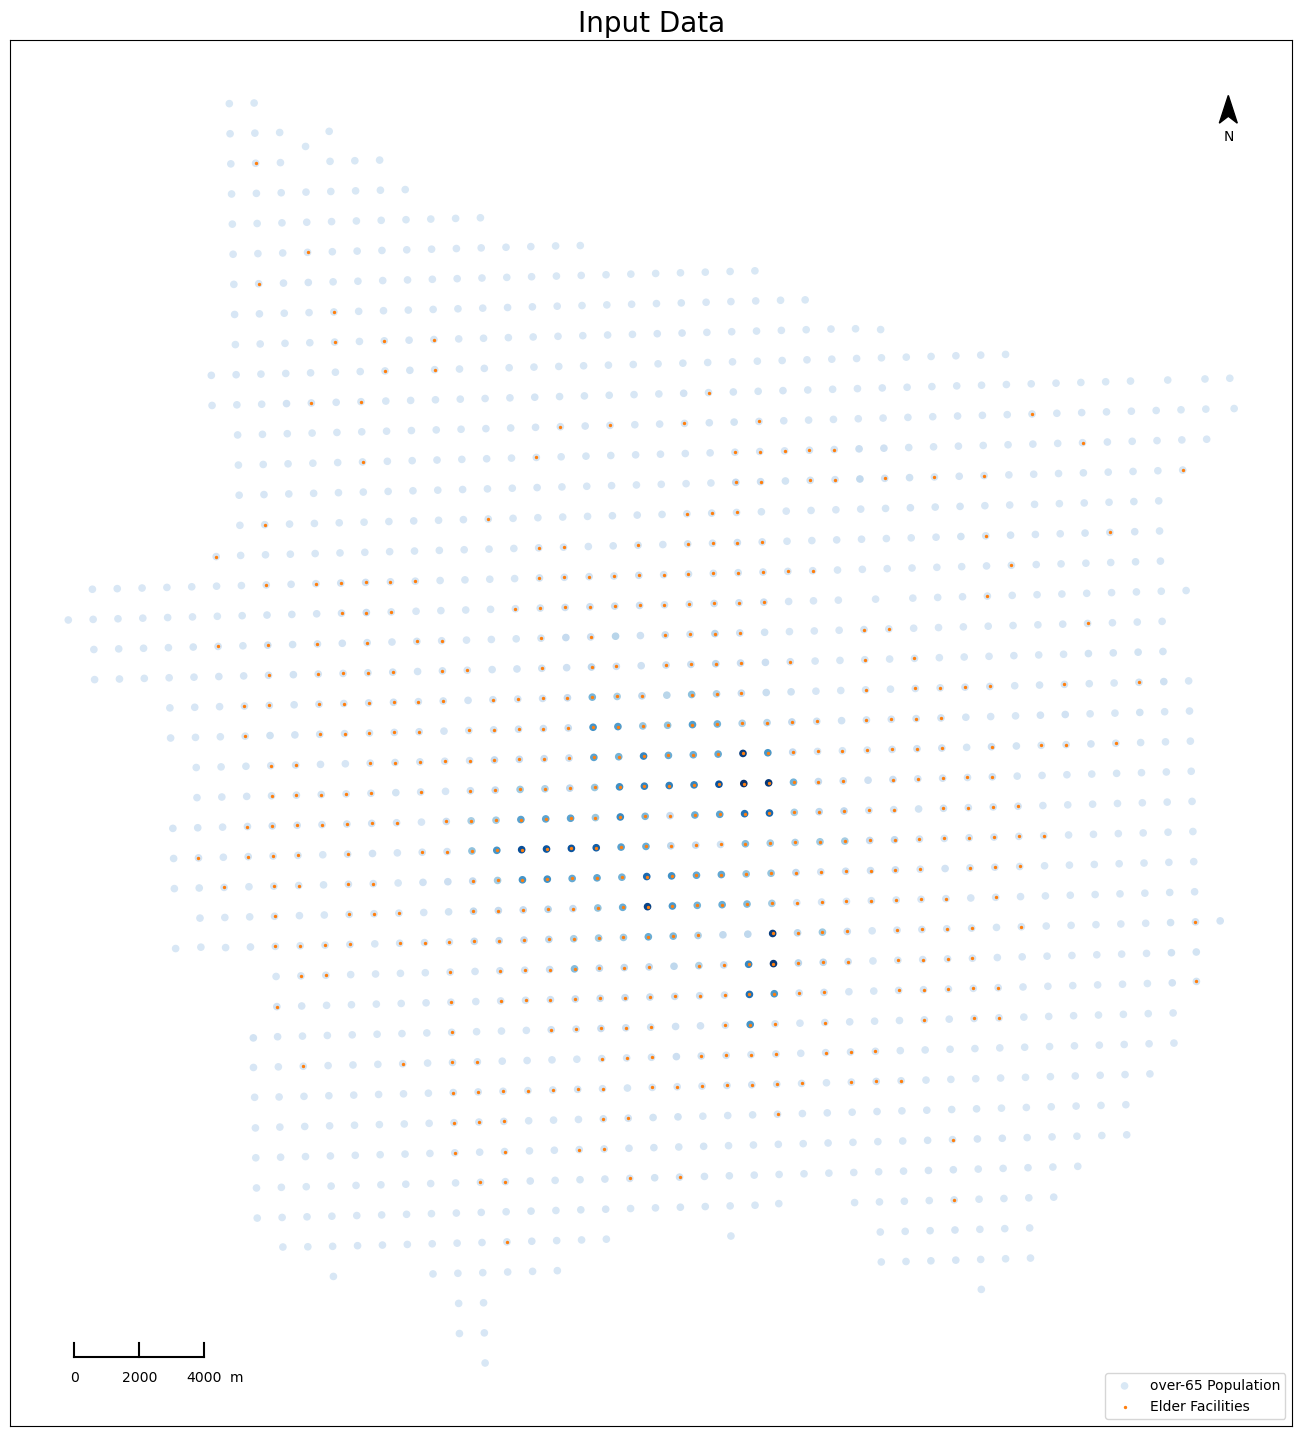

In [12]:
%%time
# 绘制输入数据的散点图
fig, ax = plt.subplots(figsize=(20,18))

# 创建一个自定义的颜色映射
cmap_blues = plt.cm.Blues
new_cmap = colors.ListedColormap(cmap_blues(np.linspace(0.15, 1, 256)))  # 使得低值区域不那么浅
# 绘制LandScan数据的散点图（按人口密度着色）
norm = plt.Normalize(ls['mianji'].min(), ls['mianji'].max())
sc = ax.scatter(ls['POINT_X'], ls['POINT_Y'], c=ls['mianji'], s=20, cmap=new_cmap, norm=norm, label='over-65 Population')
# 绘制Billboards数据的散点图
ax.scatter(ef1['POINT_X'], ef1['POINT_Y'], c='C1', s=2, label='Elder Facilities')

ax.axis('scaled')
ax.tick_params(axis='both', left=False, top=False, right=False,
               bottom=False, labelleft=False, labeltop=False,
               labelright=False, labelbottom=False)

ax.set_title("Input Data", fontsize=20)
render_scale_bar(ax = ax, x=0.05, y=0.05)
render_north_arrow(ax = ax, x = 0.95, y = 0.95, size = 0.01, ratio = 0.7)
ax.legend(loc='lower right', markerscale = 1)

In [13]:
# 根据覆盖范围从给定的点数据选择（自己定义方法，根据方法选择不同的列）
def generate_candidate_sites(sites, M=100, heuristic = None):
    # sites : Pandas dataframe 包含多个站点数据
    # M : 需要生成的候选站点数量
    # heuristic : 选择站点的启发式方法（’coverage', 'coverage_e', 'impression', 'impression_e'）
    '''
    Generate M candidate sites with the convex hull of a point set
    Input:
        sites: a Pandas DataFrame with X, Y and other characteristic
        M: the number of candidate sites to generate
        heuristic:
    Return:
        sites: a Numpy array with shape of (M,2)
    '''
    # M > sites的长度时，M设置为None ： 返回整个数据集
    if M is not None:
        if M > len(sites):
            M = None
    # 如果没有指定启发式方法，则随机选择M个站点
    if heuristic is None or heuristic == '':
        if M is None:
            return sites
        # 随机选择M个站点
        index = np.random.choice(len(sites), M)
        sites.iloc[index]
        return sites.iloc[index]
    # 根据启发式方法选择站点
    # 若为 'coverage'，则根据pop_covered_2km 进行排序
    elif heuristic == 'coverage':
        sites = sites.sort_values(by='pop_covered_2km', ascending=False).reset_index()
        if M is None:
            return sites
        sites.iloc[:M]
        return sites.iloc[:M]
    # 若为 'coverage_e'，则根据pop_covered_2km_exclusive 进行排序
    elif heuristic == 'coverage_e':
        sites = sites.sort_values(by='pop_covered_2km_exclusive', ascending=False).reset_index()
        if M is None:
            return sites
        sites.iloc[:M]
        return sites.iloc[:M]
    # 若为 'impression'，则根据weeklyImpr列 进行排序
    elif heuristic == 'impression':
        sites = sites.sort_values(by='weeklyImpr', ascending=False).reset_index()
        if M is None:
            return sites
        sites.iloc[:M]
        return sites.iloc[:M]
    # 若为 'impression_e'，则根据weeklyImpr_2km_exclusive 进行排序
    elif heuristic == 'impression_e':
        sites = sites.sort_values(by='weeklyImpr_2km_exclusive', ascending=False).reset_index()
        if M is None:
            return sites
        sites.iloc[:M]
        return sites.iloc[:M]


In [14]:
# # 给选定的站点绘制结果
# def plot_result(ls,opt_sites,radius):
#     # ls ： LandScan数据
#     # opt_sites : 优化后的站点数据
#     # radius : 站点的服务范围半径
#     '''
#     Plot the result
#     Input:
#         points: input points, Numpy array in shape of [N,2]
#         opt_sites: locations K optimal sites, Pandas DataFrame
#         radius: the radius of circle
#     '''
#     fig, ax = plt.subplots(figsize=(20,15))
#     # 根据ls中的speed_pct_freeflow_rev列绘制LandScan数据的散点图 颜色渐变
#     ls.plot(ax = ax, column=ls['mianji'], k=5, markersize=10, cmap=new_cmap, label = 'over_65 Population')
#     # 绘制优化后的站点数据的散点图的状态
#     legend_plot_flag = {'current':False,'selected':False}
#
#     # 遍历每一个优化后的站点， site 包含站点的位置信息和其他特征
#     for cnt, site in opt_sites.iterrows():
#         # 如果站点有 'current' 列且值为 True，则绘制当前的广告牌  红色 +
#         if 'current' in opt_sites.columns and site['current'] == True:#ncurrent
#             if legend_plot_flag['current'] == False:
#                 ax.scatter(site['POINT_X'], site['POINT_Y'], c='red', marker='+', s=1, label = 'Current Billboards')
#                 circlelabel = 'Service Range for Current Billboards'
#                 legend_plot_flag['current'] = True
#             ax.scatter(site['POINT_X'], site['POINT_Y'], c='red', marker='+', s=100)
# #           circle = plt.Circle(site[['POINT_X','POINT_Y']], radius, color='red', fill=False, lw=2, label = circlelabel)
#             circle = plt.Circle(site[['POINT_X','POINT_Y']], radius, color='red', fill=False, lw=2)
#
#             ax.add_artist(circle)
#         # 如果站点没有 'current' 列或值为 False，则绘制优化后的选定的广告牌  C1颜色 +
#         else:
#             if legend_plot_flag['selected'] == False:
#                 ax.scatter(site['POINT_X'], site['POINT_Y'], c='C1', marker='+', s=1, label = 'Optimized Selected Elder Facilities')
#                 circlelabel = 'Service Range for Optimized Selected Billboards'
#                 legend_plot_flag['selected'] = True
#             ax.scatter(site['POINT_X'], site['POINT_Y'], c='C1', marker='+', s=100)
# #             circle = plt.Circle(site[['POINT_X','POINT_Y']], radius, color='C1', fill=False, lw=2, label = circlelabel)
# #             circle = plt.Circle(site[['POINT_X','POINT_Y']], radius, color='C1', fill=False, lw=2)
# #             ax.add_artist(circle)
#
#     # 坐标轴设置
#     ax.axis('scaled')
#     ax.tick_params(axis='both',left=False, top=False, right=False,
#                        bottom=False, labelleft=False, labeltop=False,
#                        labelright=False, labelbottom=False)
#     title = 'Selected ' + str(len(opt_sites)) + ' Sites that Serve ' + str(radius) + ' m'
#     ax.set_title(title, fontsize=20)
#     # 绘制比例尺和指北针
#     render_scale_bar(ax = ax, x=0.05, y=0.05)
#     render_north_arrow(ax = ax, x = 0.95, y = 0.95, size = 0.01, ratio = 0.7)
#     # 添加图例
#     ax.legend(loc='lower right', markerscale = 10)
#     return ax

In [15]:
# 求解
np.random.seed() # 生成随机种子
ef_ = generate_candidate_sites(ef, M=None, heuristic="") # 生成候选站点数据（返回所有站点）
users = np.array(ls[['NORM_X', 'NORM_Y']]) # ls转化为 Numpy 数组
facilities_all = np.array(ef_[['NORM_X', 'NORM_Y']]) # bbs_转化为 Numpy 数组
# demand = np.array(ls['speed_pct_freeflow_rev_norm'])
# demand = np.array(ls['mianji']) # 列speed_pct_freeflow_rev 交通流作为需求量
demand = np.array(ls['mianji']) # 列speed_pct_freeflow_rev 交通流作为需求量
PN = 20 # M = 20
real_radius = 2000 # 真实的服务范围半径
radius = real_radius/S # 将真实的服务范围半径归一化到[0, 1]区间

# 计算了所有设施与所有用户之间的欧几里得距离
A = np.sum((facilities_all[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5

# 生成覆盖矩阵 A[i,j] = 1 表示设施点i可以覆盖需求点j，A[i,j] = 0 表示设施点i不能覆盖需求点j
mask1 = A <= radius
A[mask1] = 1
A[~mask1] = 0
print(S)

38686.09400000004


In [16]:
# gurobi求解值

start = time.time()

w1 = 0.6  # Weight for C_hat (effective coverage)
w2 = 0.4  # Weight for (1 - D_hat) (accessibility)
da = 1000 / S  # Distance tolerance lower bound (normalised)
db = 2000 / S  # Distance tolerance upper bound (normalised)

res = gurobi_solver_EF_MCLP(users, facilities_all, demand, PN, A, w1, w2, da, db)

print(f"Objective f_hat         : {res['obj']:.6f}")
print(f"C_hat                   : {res['C_hat']:.6f}")
print(f"D_hat                   : {res['D_hat']:.6f}")
print(f"Accessibility (1-D_hat) : {res['accessibility_term']:.6f}")
print(f"Coverage rate           : {res['coverage_rate']:.2%}")
print(f"Covered demand          : {res['covered_demand']:.0f} / {res['total_demand']:.0f}")
print(f"Weighted travel dist    : {res['weighted_travel_distance']:.6f}  (normalised units)")
solutions = res['selected_facilities']
end = time.time() - start
print(f"Running time            : {end:.4f} s")
print(f"Selected facilities     : {solutions}")
# # 开始循环
# objective_values = []
# execution_times = []
#
# # 定义循环次数
# num_iterations = 1000
# for i in range(num_iterations):
#     start_run_time = time.time()
#
#     # 1. 从421个候选点中随机选择100个
#     candidate_indices = np.random.choice(len(facilities_all), 100, replace=False)
#     facilities = facilities_all[candidate_indices]
#
#     # 2. 为当前选定的100个设施点生成覆盖矩阵A
#     A = np.sum((facilities[:, np.newaxis, :] - users[np.newaxis, :, :]) ** 2, axis=-1) ** 0.5
#     mask1 = A <= radius
#     A[mask1] = 1
#     A[~mask1] = 0
#
#     # 3. 调用Gurobi求解器
#     x_result, y_result, obj, coverage_rate, covered_demand, total_demand, assign_j = gurobi_solver_EF_MCLP(
#         users, facilities, demand, PN, A, w1, w2, da, db, D_max
#     )
#
#
#     end_run_time = time.time()
#
#     # 4. 记录本次运行的目标值和时间
#     objective_values.append(obj)
#     execution_times.append(end_run_time - start_run_time)
#
#     # (可选) 打印每次迭代的进度
#     print(f"迭代 {i+1}/{num_iterations} 完成: Obj = {obj:.2f}, 时间 = {end_run_time - start_run_time:.4f}s")
#
#
# # --- 循环结束后计算并输出平均值 ---
#
# average_objective = np.mean(objective_values)
# average_time = np.mean(execution_times)
#
# print("\\n" + "="*50)
# print(f"在 {num_iterations} 次随机抽样运行后:")
# print(f"平均目标函数值 (Average obj): {average_objective:.4f}")
# print(f"平均运行时间 (Average time): {average_time:.4f} 秒")
# print("="*50)

Set parameter LicenseID to value 2758298
Objective f_hat         : 0.689805
C_hat                   : 0.637151
D_hat                   : 0.231215
Accessibility (1-D_hat) : 0.768785
Coverage rate           : 64.64%
Covered demand          : 248491 / 384406
Weighted travel dist    : 0.018491  (normalised units)
Running time            : 0.9754 s
Selected facilities     : [89, 109, 150, 153, 181, 206, 209, 232, 241, 259, 263, 273, 290, 294, 298, 322, 347, 351, 367, 394]


### EF-MCLP 权重敏感性实验（审稿补充）

固定距离阈值 `da, db, D_max` 与覆盖矩阵 `A`（与主实验一致）。对预算 **M ∈ {20, 30}** 与权重组合 **(w1, w2) ∈ {(0.2, 0.8), (0.4, 0.6), (0.6, 0.4), (0.8, 0.2)}** 分别求解。

**指标定义**

- **Coverage ratio（覆盖率）**：已覆盖需求量 / 总需求量，即 $\big(\sum_j demand_j \cdot y_j\big) / \sum_j demand_j$，其中 $y_j=1$ 表示需求点 $j$ 被任一选中设施服务（与模型中的分配一致）。不同权重下最优选址不同，该比例会变化。
- **Demand-weighted mean service distance (m)**：$\sum_j demand_j \cdot d_{ij}^{(m)} \cdot y_{ij} \,/\, \sum_j demand_j \cdot y_{ij}$，其中 $d_{ij}^{(m)} = d_{ij}^{(\mathrm{norm})} \cdot S$ 为米。
- **Normalized EF-MCLP objective**：$Z^\ast = \mathrm{Obj} / \sum_j demand_j$（总需求归一化后的目标值，便于跨权重比较）。
- **Relative change vs. baseline**：baseline 为 **(w1, w2) = (0.6, 0.4)**，在同一预算 $M$ 下，$(Z^\ast - Z^\ast_{\mathrm{base}}) / |Z^\ast_{\mathrm{base}}| \times 100\%$（表中数值单位为百分比百分点）。

In [17]:
# EF-MCLP (w1, w2) 敏感性分析：仅输出目标函数值
from IPython.display import display

def run_weight_sensitivity(users, facilities, demand, budgets, weight_list,
                           A, da, db, baseline_w1=0.6):
    """
    Solve EF-MCLP for every (budget, w1) combination and collect results.

    Parameters
    ----------
    budgets      : list of int,   e.g. [20, 30]
    weight_list  : list of float, e.g. [0.1, ..., 0.9]  (w1 values; w2 = 1 - w1)
    baseline_w1  : reference w1 for the relative-change column

    Returns
    -------
    pandas.DataFrame with one row per (budget, w1) combination.
    """
    rows = []
    for M_budget in budgets:
        # Solve all w1 values for this budget, then compute relative change
        results_by_w1 = {}
        for w1 in weight_list:
            w2 = round(1.0 - w1, 10)
            res = gurobi_solver_EF_MCLP(
                users, facilities, demand, M_budget, A, w1, w2, da, db
            )
            results_by_w1[w1] = res

        baseline_obj = results_by_w1[baseline_w1]['obj']

        for w1 in weight_list:
            w2 = round(1.0 - w1, 10)
            res = results_by_w1[w1]
            if abs(baseline_obj) > 1e-12:
                rel_pct = (res['obj'] - baseline_obj) / abs(baseline_obj) * 100.0
            else:
                rel_pct = float('nan')
            rows.append({
                'Budget_M':                        M_budget,
                'w1':                              w1,
                'w2':                              w2,
                'EF_MCLP_Objective':               res['obj'],
                'C_hat':                           res['C_hat'],
                'D_hat':                           res['D_hat'],
                'Accessibility_Term':              res['accessibility_term'],
                'Coverage_Rate':                   res['coverage_rate'],
                'Covered_Demand':                  res['covered_demand'],
                'Weighted_Travel_Distance':        res['weighted_travel_distance'],
                'Relative_Change_vs_Baseline_pct': rel_pct,
            })

    return pd.DataFrame(rows)


def make_main_text_table(df, representative_weights=None):
    """
    Compact table for the paper body.
    Keeps only representative w1 rows and the most informative columns.
    """
    if representative_weights is None:
        representative_weights = [0.4, 0.5, 0.6, 0.7, 0.8]
    subset = df[df['w1'].isin(representative_weights)].copy()
    cols = ['Budget_M', 'w1', 'w2', 'C_hat', 'Accessibility_Term',
            'Weighted_Travel_Distance', 'EF_MCLP_Objective']
    return subset[cols].reset_index(drop=True)


def make_appendix_table(df):
    """Full sensitivity results table for the appendix."""
    return df.copy().reset_index(drop=True)


# --- Run sensitivity analysis ---
BUDGETS_SENS = [20, 30]
WEIGHT_LIST  = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
BASELINE_W1  = 0.6

sensitivity_df = run_weight_sensitivity(
    users, facilities_all, demand,
    budgets=BUDGETS_SENS,
    weight_list=WEIGHT_LIST,
    A=A, da=da, db=db,
    baseline_w1=BASELINE_W1,
)

print("=== Full Sensitivity Results ===")
display(sensitivity_df)

print("\n=== Main Text Table (representative weights only) ===")
main_table = make_main_text_table(sensitivity_df)
display(main_table)
print(main_table.to_latex(index=False, float_format='%.4f'))

print("\n=== Appendix Table (all weights) ===")
appendix_table = make_appendix_table(sensitivity_df)
display(appendix_table)
print(appendix_table.to_latex(index=False, float_format='%.4f'))


=== Full Sensitivity Results ===


,Budget_M,w1,w2,EF_MCLP_Objective,C_hat,D_hat,Accessibility_Term,Coverage_Rate,Covered_Demand,Weighted_Travel_Distance,Relative_Change_vs_Baseline_pct
0,20,0.1,0.9,0.921672,0.216716,0.000000,1.000000,0.216716,83307.0,0.000000,33.613437
1,20,0.2,0.8,0.843343,0.216716,0.000000,1.000000,0.216716,83307.0,0.000000,22.258281
2,20,0.3,0.7,0.769480,0.370462,0.059512,0.940488,0.370462,142408.0,0.008305,11.550490
3,20,0.4,0.6,0.727352,0.565899,0.165013,0.834987,0.571352,219631.0,0.014931,5.443201
4,20,0.5,0.5,0.706359,0.610999,0.198281,0.801719,0.617280,237286.0,0.016606,2.399870
5,20,0.6,0.4,0.689805,0.637151,0.231215,0.768785,0.646429,248491.0,0.018491,0.000000
6,20,0.7,0.3,0.681015,0.662556,0.275913,0.724087,0.687409,264244.0,0.020751,-1.274199
7,20,0.8,0.2,0.676371,0.668624,0.292641,0.707359,0.696438,267715.0,0.021723,-1.947453
8,20,0.9,0.1,0.672628,0.670160,0.305164,0.694836,0.710468,273108.0,0.022206,-2.490121
9,30,0.1,0.9,0.929209,0.292090,0.000000,1.000000,0.292090,112281.0,0.000000,27.801774



=== Main Text Table (representative weights only) ===


,Budget_M,w1,w2,C_hat,Accessibility_Term,Weighted_Travel_Distance,EF_MCLP_Objective
0,20,0.4,0.6,0.565899,0.834987,0.014931,0.727352
1,20,0.5,0.5,0.610999,0.801719,0.016606,0.706359
2,20,0.6,0.4,0.637151,0.768785,0.018491,0.689805
3,20,0.7,0.3,0.662556,0.724087,0.020751,0.681015
4,20,0.8,0.2,0.668624,0.707359,0.021723,0.676371
5,30,0.4,0.6,0.614379,0.850811,0.012470,0.756238
6,30,0.5,0.5,0.672593,0.801721,0.015104,0.737157
7,30,0.6,0.4,0.693613,0.777256,0.016430,0.727070
8,30,0.7,0.3,0.720457,0.727136,0.019182,0.722461
9,30,0.8,0.2,0.724596,0.713514,0.019894,0.722379


\begin{tabular}{rrrrrrr}
\toprule
Budget_M & w1 & w2 & C_hat & Accessibility_Term & Weighted_Travel_Distance & EF_MCLP_Objective \\
\midrule
20 & 0.4000 & 0.6000 & 0.5659 & 0.8350 & 0.0149 & 0.7274 \\
20 & 0.5000 & 0.5000 & 0.6110 & 0.8017 & 0.0166 & 0.7064 \\
20 & 0.6000 & 0.4000 & 0.6372 & 0.7688 & 0.0185 & 0.6898 \\
20 & 0.7000 & 0.3000 & 0.6626 & 0.7241 & 0.0208 & 0.6810 \\
20 & 0.8000 & 0.2000 & 0.6686 & 0.7074 & 0.0217 & 0.6764 \\
30 & 0.4000 & 0.6000 & 0.6144 & 0.8508 & 0.0125 & 0.7562 \\
30 & 0.5000 & 0.5000 & 0.6726 & 0.8017 & 0.0151 & 0.7372 \\
30 & 0.6000 & 0.4000 & 0.6936 & 0.7773 & 0.0164 & 0.7271 \\
30 & 0.7000 & 0.3000 & 0.7205 & 0.7271 & 0.0192 & 0.7225 \\
30 & 0.8000 & 0.2000 & 0.7246 & 0.7135 & 0.0199 & 0.7224 \\
\bottomrule
\end{tabular}


=== Appendix Table (all weights) ===


,Budget_M,w1,w2,EF_MCLP_Objective,C_hat,D_hat,Accessibility_Term,Coverage_Rate,Covered_Demand,Weighted_Travel_Distance,Relative_Change_vs_Baseline_pct
0,20,0.1,0.9,0.921672,0.216716,0.000000,1.000000,0.216716,83307.0,0.000000,33.613437
1,20,0.2,0.8,0.843343,0.216716,0.000000,1.000000,0.216716,83307.0,0.000000,22.258281
2,20,0.3,0.7,0.769480,0.370462,0.059512,0.940488,0.370462,142408.0,0.008305,11.550490
3,20,0.4,0.6,0.727352,0.565899,0.165013,0.834987,0.571352,219631.0,0.014931,5.443201
4,20,0.5,0.5,0.706359,0.610999,0.198281,0.801719,0.617280,237286.0,0.016606,2.399870
5,20,0.6,0.4,0.689805,0.637151,0.231215,0.768785,0.646429,248491.0,0.018491,0.000000
6,20,0.7,0.3,0.681015,0.662556,0.275913,0.724087,0.687409,264244.0,0.020751,-1.274199
7,20,0.8,0.2,0.676371,0.668624,0.292641,0.707359,0.696438,267715.0,0.021723,-1.947453
8,20,0.9,0.1,0.672628,0.670160,0.305164,0.694836,0.710468,273108.0,0.022206,-2.490121
9,30,0.1,0.9,0.929209,0.292090,0.000000,1.000000,0.292090,112281.0,0.000000,27.801774


\begin{tabular}{rrrrrrrrrrr}
\toprule
Budget_M & w1 & w2 & EF_MCLP_Objective & C_hat & D_hat & Accessibility_Term & Coverage_Rate & Covered_Demand & Weighted_Travel_Distance & Relative_Change_vs_Baseline_pct \\
\midrule
20 & 0.1000 & 0.9000 & 0.9217 & 0.2167 & 0.0000 & 1.0000 & 0.2167 & 83307.0000 & 0.0000 & 33.6134 \\
20 & 0.2000 & 0.8000 & 0.8433 & 0.2167 & 0.0000 & 1.0000 & 0.2167 & 83307.0000 & 0.0000 & 22.2583 \\
20 & 0.3000 & 0.7000 & 0.7695 & 0.3705 & 0.0595 & 0.9405 & 0.3705 & 142408.0000 & 0.0083 & 11.5505 \\
20 & 0.4000 & 0.6000 & 0.7274 & 0.5659 & 0.1650 & 0.8350 & 0.5714 & 219631.0000 & 0.0149 & 5.4432 \\
20 & 0.5000 & 0.5000 & 0.7064 & 0.6110 & 0.1983 & 0.8017 & 0.6173 & 237286.0000 & 0.0166 & 2.3999 \\
20 & 0.6000 & 0.4000 & 0.6898 & 0.6372 & 0.2312 & 0.7688 & 0.6464 & 248491.0000 & 0.0185 & 0.0000 \\
20 & 0.7000 & 0.3000 & 0.6810 & 0.6626 & 0.2759 & 0.7241 & 0.6874 & 264244.0000 & 0.0208 & -1.2742 \\
20 & 0.8000 & 0.2000 & 0.6764 & 0.6686 & 0.2926 & 0.7074 & 0.6964 & 267

<Axes: title={'center': 'Selected 20 Sites that Serve 2000 m(Gurobi)'}>

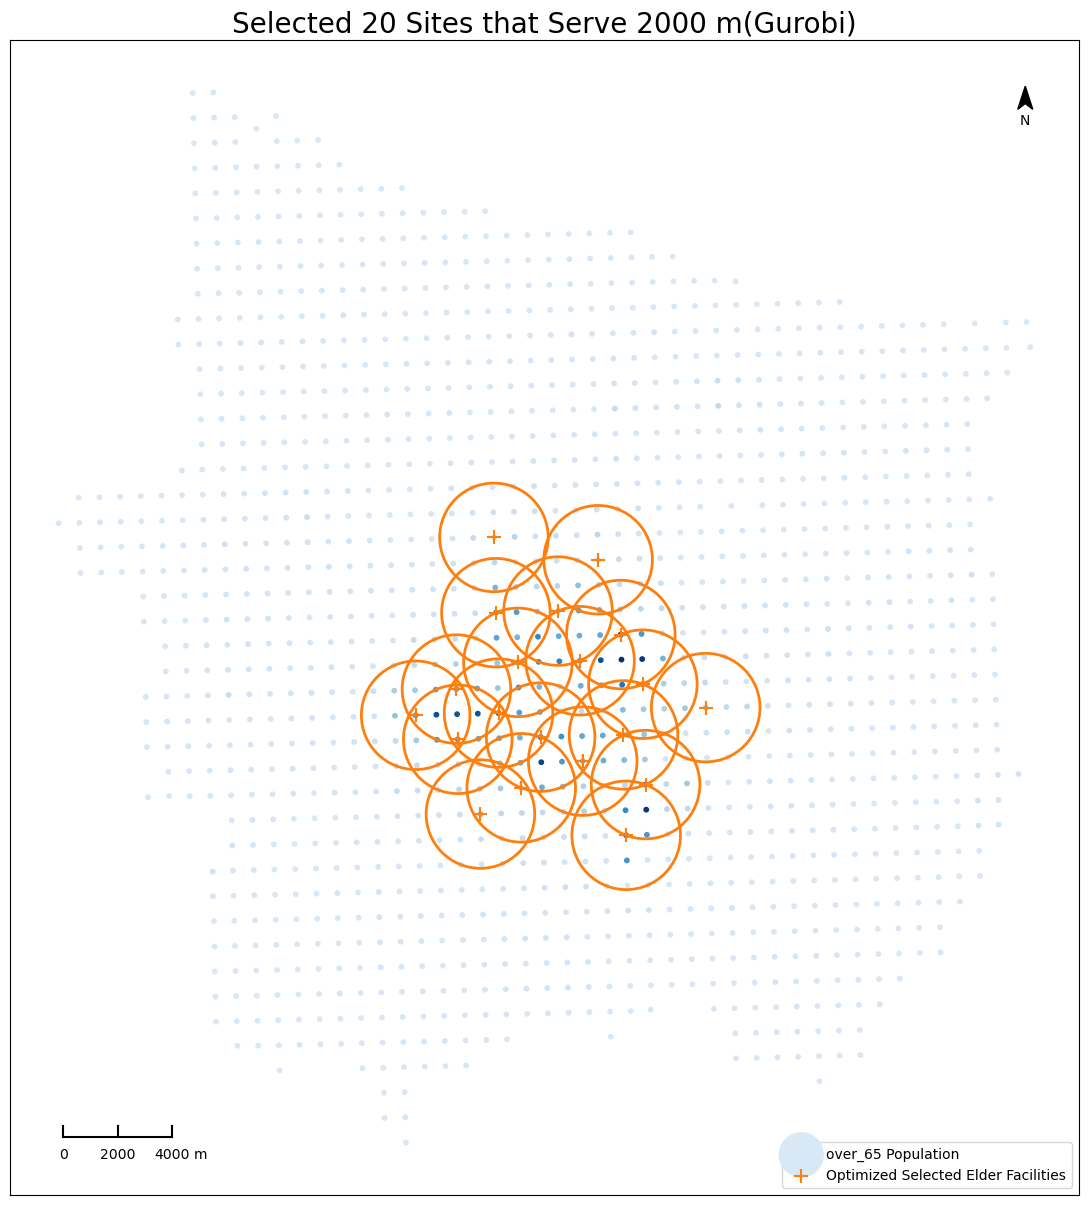

In [18]:
# 给选定的站点绘制结果
def plot_result(ls,opt_sites,radius):
    # ls ： LandScan数据
    # opt_sites : 优化后的站点数据
    # radius : 站点的服务范围半径
    '''
    Plot the result
    Input:
        points: input points, Numpy array in shape of [N,2]
        opt_sites: locations K optimal sites, Pandas DataFrame
        radius: the radius of circle
    '''
    fig, ax = plt.subplots(figsize=(20,15))
    # 绘制LandScan数据的散点图（按人口密度着色）
    norm_pop = plt.Normalize(ls['mianji'].min(), ls['mianji'].max())
    ax.scatter(ls['POINT_X'], ls['POINT_Y'], c=ls['mianji'], s=10, cmap=new_cmap, norm=norm_pop, label='over_65 Population')
    # 绘制优化后的站点数据的散点图的状态
    legend_plot_flag = {'current':False,'selected':False}

    # 遍历每一个优化后的站点， site 包含站点的位置信息和其他特征
    for cnt, site in opt_sites.iterrows():
        # 如果站点有 'current' 列且值为 True，则绘制当前的广告牌  红色 +
        if 'current' in opt_sites.columns and site['current'] == True:#ncurrent
            if legend_plot_flag['current'] == False:
                ax.scatter(site['POINT_X'], site['POINT_Y'], c='red', marker='+', s=1, label = 'Current Billboards')
                circlelabel = 'Service Range for Current Billboards'
                legend_plot_flag['current'] = True
            ax.scatter(site['POINT_X'], site['POINT_Y'], c='red', marker='+', s=100)
            circle = plt.Circle((site['POINT_X'], site['POINT_Y']), radius, color='red', fill=False, lw=2)
            ax.add_artist(circle)
        # 如果站点没有 'current' 列或值为 False，则绘制优化后的选定的广告牌  C1颜色 +
        else:
            if legend_plot_flag['selected'] == False:
                ax.scatter(site['POINT_X'], site['POINT_Y'], c='C1', marker='+', s=1, label = 'Optimized Selected Elder Facilities')
                circlelabel = 'Service Range for Optimized Selected Billboards'
                legend_plot_flag['selected'] = True
            ax.scatter(site['POINT_X'], site['POINT_Y'], c='C1', marker='+', s=100)
            circle = plt.Circle((site['POINT_X'], site['POINT_Y']), radius, color='C1', fill=False, lw=2)
            ax.add_artist(circle)

    # 坐标轴设置
    ax.axis('scaled')
    ax.tick_params(axis='both',left=False, top=False, right=False,
                       bottom=False, labelleft=False, labeltop=False,
                       labelright=False, labelbottom=False)
    ax.grid(False)
    title = 'Selected ' + str(len(opt_sites)) + ' Sites that Serve ' + str(radius) + ' m(Gurobi)'
    ax.set_title(title, fontsize=20)
    # 绘制比例尺和指北针
    render_scale_bar(ax = ax, x=0.05, y=0.05)
    render_north_arrow(ax = ax, x = 0.95, y = 0.95, size = 0.01, ratio = 0.7)
    # 添加图例
    ax.legend(loc='lower right', markerscale = 10)
    return ax
opt_sites = ef_.iloc[solutions]  # Get the selected facilities based on the solutions

plot_result(ls,opt_sites,real_radius)